In [1]:
from resources.helper.helper_dataset import get_dataloaders_cifar10
from resources.helper.helper_evaluation import set_all_seeds, set_deterministic
from resources.helper.helper_train import train_model
from resources.helper.helper_plotting import plot_training_loss, plot_accuracy, show_examples

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [3]:
resize_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])
test_resize_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])

train_loader, valid_loader, test_loader = get_dataloaders_cifar10(batch_size=256,validation_fraction=0.1, 
                                                                train_transforms=resize_transform,test_transforms=resize_transform)

In [4]:
for images, labels in train_loader:  
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    print('Class labels of 10 examples:', labels[:10])
    break

Image batch dimensions: torch.Size([256, 3, 32, 32])
Image label dimensions: torch.Size([256])
Class labels of 10 examples: tensor([0, 6, 9, 3, 0, 6, 5, 2, 9, 3])


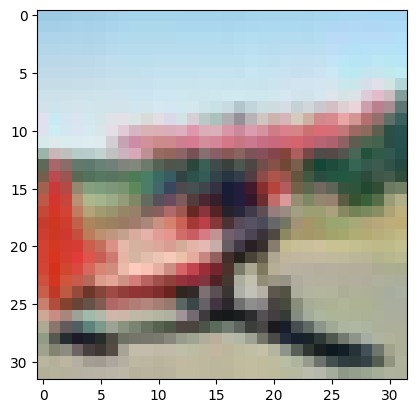

In [5]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
img = images[1]
img = img / 2 + 0.5
npimg = img.numpy()
plt.imshow(np.transpose(npimg, (1, 2, 0)))

plt.show()


In [6]:
class AllConvNet(torch.nn.Module):
    def __init__(self, classes):
        super().__init__()
        self.classes = classes
        self.layers = torch.nn.Sequential(
            #if kernal has different height and width it can be as(3,4) and same in stride it can also be assigned as (1,2)
               torch.nn.Conv2d(in_channels=3,
                                      out_channels=16,
                                      kernel_size=3,
                                      stride=1,
                                      padding=1,
                                      bias=False),
                      torch.nn.BatchNorm2d(16),
                      torch.nn.ReLU(inplace=True),
                      torch.nn.Conv2d(in_channels=16,
                                      out_channels=16,
                                      kernel_size=3,
                                      stride=2,
                                      padding=1,
                                      bias=False),   
                      torch.nn.BatchNorm2d(16),
                      torch.nn.ReLU(inplace=True),
                      torch.nn.Conv2d(in_channels=16,
                                      out_channels=32,
                                      kernel_size=3,
                                      stride=1,
                                      padding=1,
                                      bias=False),        
                      torch.nn.BatchNorm2d(32),
                      torch.nn.ReLU(inplace=True),                        
                      torch.nn.Conv2d(in_channels=32,
                                      out_channels=32,
                                      kernel_size=3,
                                      stride=2,
                                      padding=1,
                                      bias=False),      
                      torch.nn.BatchNorm2d(32),
                      torch.nn.ReLU(inplace=True),       
                      torch.nn.Conv2d(in_channels=32,
                                      out_channels=64,
                                      kernel_size=3,
                                      stride=(1, 1),
                                      padding=1,
                                      bias=False),   
                      torch.nn.BatchNorm2d(64),
                      torch.nn.ReLU(inplace=True),
                      torch.nn.Conv2d(in_channels=64,
                                      out_channels=64,
                                      kernel_size=3,
                                      stride=2,
                                      padding=1,
                                      bias=False),     
                      torch.nn.BatchNorm2d(64),
                      torch.nn.ReLU(inplace=True),
                      torch.nn.Conv2d(in_channels=64,
                                      out_channels=classes,
                                      kernel_size=3,
                                      stride=1,
                                      padding=1,
                                      bias=False),    
                      torch.nn.BatchNorm2d(10),
                      torch.nn.ReLU(inplace=True),
                      torch.nn.AdaptiveAvgPool2d(1),
                      torch.nn.Flatten())

    def forward(self, x):
        logits = self.layers(x)
        return logits

Epoch: 001/005 | Batch 0000/0175 | Loss: 2.3208
Epoch: 001/005 | Batch 0050/0175 | Loss: 1.8611
Epoch: 001/005 | Batch 0100/0175 | Loss: 1.6903
Epoch: 001/005 | Batch 0150/0175 | Loss: 1.6302
Epoch: 001/005 | Train: 44.14% | Validation: 44.58%
Time elapsed: 1.01 min
Last lr:  [0.1]
Epoch: 002/005 | Batch 0000/0175 | Loss: 1.3875
Epoch: 002/005 | Batch 0050/0175 | Loss: 1.4991
Epoch: 002/005 | Batch 0100/0175 | Loss: 1.3786
Epoch: 002/005 | Batch 0150/0175 | Loss: 1.3261
Epoch: 002/005 | Train: 53.54% | Validation: 51.78%
Time elapsed: 2.19 min
Last lr:  [0.1]
Epoch: 003/005 | Batch 0000/0175 | Loss: 1.2786
Epoch: 003/005 | Batch 0050/0175 | Loss: 1.2363
Epoch: 003/005 | Batch 0100/0175 | Loss: 1.1685
Epoch: 003/005 | Batch 0150/0175 | Loss: 1.0957
Epoch: 003/005 | Train: 60.24% | Validation: 58.18%
Time elapsed: 2.71 min
Last lr:  [0.1]
Epoch: 004/005 | Batch 0000/0175 | Loss: 1.0021
Epoch: 004/005 | Batch 0050/0175 | Loss: 1.0732
Epoch: 004/005 | Batch 0100/0175 | Loss: 1.0746
Epoch: 

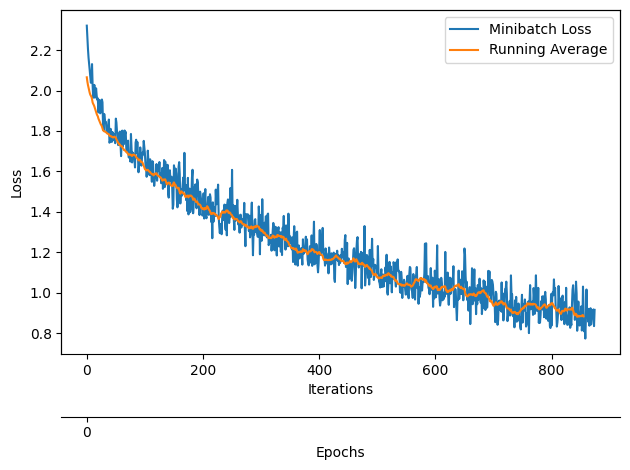

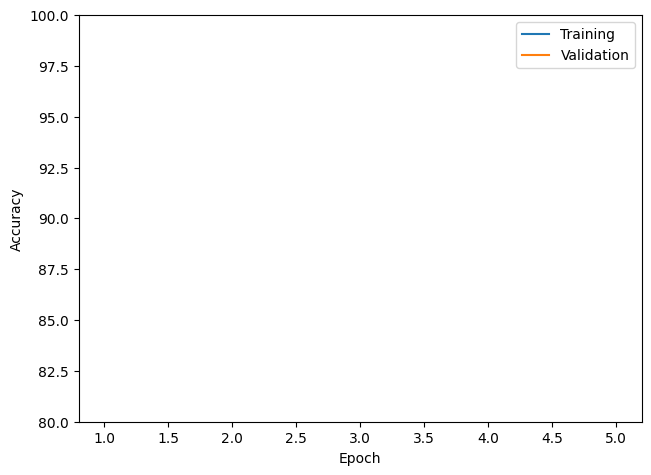

In [7]:
model=AllConvNet(10)
model=model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,factor=0.1, mode='max')
Epochs=5
minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model=model,
    num_epochs=Epochs,
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    device=device,
    logging_interval=50,
    scheduler=scheduler,
    scheduler_on='valid_acc')

plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=Epochs,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=20)

plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)

plt.ylim([80, 100])
plt.show()